In [9]:
!git clone https://github.com/BiDAlab/DeepFakesON-Phys.git

fatal: destination path 'DeepFakesON-Phys' already exists and is not an empty directory.


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

IMG_SIZE     = (36, 36)
BATCH_SIZE   = 32
EPOCHS       = 20
INIT_LR      = 1e-4
PRETRAINED_MODEL_PATH = "/kaggle/working/DeepFakesON-Phys/pretrained models/DeepFakesON-Phys_CelebDF_V2.h5"
DATASET_ROOT = "/kaggle/input/datasets/mariaspasyuk/trainframesfaces"  

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

def flatten(vid_list):
    curr, prev, lbls = [], [], []
    for frames, lbl in vid_list:
        for i in range(len(frames)):
            curr.append(frames[i])
            prev.append(frames[i] if i == 0 else frames[i-1])
            lbls.append(lbl)
    return curr, prev, lbls
def build_dataset_paths(data_dir, val_split=0.2):
    data_dir = Path(data_dir)
    videos_data = []

    for label_name in ["real_frames_faces", "fake_frames_faces"]:
        label = 0 if label_name == "real_frames_faces" else 1
        class_dir = data_dir / label_name
        if not class_dir.exists():
            print(f"{class_dir} не найдена")
            continue
        for video_dir in class_dir.iterdir():
            if not video_dir.is_dir(): continue
            frames = sorted(video_dir.glob("*.png")) + sorted(video_dir.glob("*.jpg"))
            frames = [str(f) for f in frames if f.is_file()]
            if len(frames) < 2: continue
            videos_data.append((frames, label))
    print("here")
            
    if not videos_data:
        raise ValueError("Датасет пуст или структура не соответствует ожидаемой (real/fake -> video_dir -> frames)")
        
    train_vids, val_vids = train_test_split(videos_data, test_size=val_split, random_state=42)
    print("here2")
    
    train_curr, train_prev, train_lbls = flatten(train_vids)
    print("here3")
    val_curr, val_prev, val_lbls = flatten(val_vids)
    
    print(f"Train: {len(train_curr)} кадров, Val: {len(val_curr)} кадров")
    return (train_curr, train_prev, train_lbls), (val_curr, val_prev, val_lbls)

def load_and_process_tf(curr_path, prev_path, label):
    def _py_load(c_path, p_path):
        c_str = c_path.numpy().decode('utf-8')
        p_str = p_path.numpy().decode('utf-8')
        
        c_img = cv2.imread(c_str)
        p_img = cv2.imread(p_str)
        if c_img is None or p_img is None:
            return np.zeros((3, 36, 36), dtype=np.float32), np.zeros((3, 36, 36), dtype=np.float32)
            
        c_img = cv2.cvtColor(c_img, cv2.COLOR_BGR2RGB)
        p_img = cv2.cvtColor(p_img, cv2.COLOR_BGR2RGB)
        c_img = cv2.resize(c_img, IMG_SIZE).astype(np.float32) / 255.0
        p_img = cv2.resize(p_img, IMG_SIZE).astype(np.float32) / 255.0

        raw = np.transpose(c_img, (2, 0, 1))
        prev_raw = np.transpose(p_img, (2, 0, 1))
        diff = raw - prev_raw  
        
        return raw, diff

    raw, diff = tf.py_function(_py_load, [curr_path, prev_path], [tf.float32, tf.float32])
    raw.set_shape((3, 36, 36))
    diff.set_shape((3, 36, 36))
    return (raw, diff), label

def make_tf_dataset(curr, prev, lbls, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((curr, prev, lbls))
    if shuffle:
        ds = ds.shuffle(buffer_size=5000, reshuffle_each_iteration=True)
    ds = ds.map(load_and_process_tf, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

def prepare_model_for_finetuning(model_path, unfreeze_ratio=0.2):
    print(f"Загрузка модели из: {model_path}")
    model = tf.keras.models.load_model(model_path, compile=False)
    print(f"Входы модели: {[inp.shape for inp in model.inputs]}")
    
    total = len(model.layers)
    freeze_until = int(total * (1 - unfreeze_ratio))
    for i, layer in enumerate(model.layers):
        layer.trainable = i >= freeze_until
    print(f"Разморожено {total - freeze_until} слоёв из {total}")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(INIT_LR),
        loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
        metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model

if __name__ == "__main__":
    (tr_curr, tr_prev, tr_lbls), (vl_curr, vl_prev, vl_lbls) = build_dataset_paths(DATASET_ROOT)
    
    train_ds = make_tf_dataset(tr_curr, tr_prev, tr_lbls, shuffle=True)
    val_ds   = make_tf_dataset(vl_curr, vl_prev, vl_lbls, shuffle=False)

    print("Тестовая загрузка батча")
    sample_batch = next(iter(train_ds))
    print(f" Форма входа: {sample_batch[0][0].shape}, Метки: {sample_batch[1].shape}")
    
    model = prepare_model_for_finetuning(PRETRAINED_MODEL_PATH)
    model.summary()
    
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, monitor="val_auc"),
        tf.keras.callbacks.ModelCheckpoint("/kaggle/working/finetuned_DeepFakesON-Phys.h5", 
                                           save_best_only=True, monitor="val_auc"),
        tf.keras.callbacks.CSVLogger("/kaggle/working/training_log.csv")
    ]
    
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['auc'], label='Train AUC')
    plt.plot(history.history['val_auc'], label='Val AUC')
    plt.legend(); plt.title('AUC')
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend(); plt.title('Loss')
    plt.show()
    
    print("Веса: /kaggle/working/finetuned_DeepFakesON-Phys.h5")

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, roc_curve
import matplotlib.pyplot as plt

FINETUNED_MODEL_PATH = "/kaggle/working/finetuned_DeepFakesON-Phys.h5"
DATASET_ROOT         = "/kaggle/input/datasets/mariaspasyuk/testframesfaces" 
IMG_SIZE             = (36, 36)
INFERENCE_BATCH_SIZE = 64
AGGREGATION_METHOD   = "mean" 
THRESHOLD            = 0.3


def load_model_safe(model_path):
    print(f"Загрузка модели: {model_path}")
    model = tf.keras.models.load_model(model_path, compile=False)
    print(f"Модель загружена. Входы: {[inp.shape for inp in model.inputs]}")
    return model

def load_video_frames(frame_dir, target_size=IMG_SIZE):
    frame_paths = sorted(Path(frame_dir).glob("*.png")) + sorted(Path(frame_dir).glob("*.jpg"))
    if not frame_paths:
        return None, None

    frames = []
    for p in frame_paths:
        img = cv2.imread(str(p))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, target_size).astype(np.float32) / 255.0
        frames.append(img)

    if len(frames) == 0:
        return None, None

    raw = np.array(frames)  
    diff = np.zeros_like(raw)
    diff[1:] = raw[1:] - raw[:-1] 

    raw_nchw = np.transpose(raw, (0, 3, 1, 2))
    diff_nchw = np.transpose(diff, (0, 3, 1, 2))
    return raw_nchw, diff_nchw

def predict_video_score(model, frame_dir, batch_size=INFERENCE_BATCH_SIZE, agg_method=AGGREGATION_METHOD):
    raw, diff = load_video_frames(frame_dir)
    if raw is None:
        return None

    frame_scores = []
    for i in range(0, len(raw), batch_size):
        preds = model([raw[i:i+batch_size], diff[i:i+batch_size]], training=False).numpy()
        frame_scores.append(preds.flatten())

    frame_scores = np.concatenate(frame_scores)

    if agg_method == "mean":   return np.mean(frame_scores)
    elif agg_method == "median": return np.median(frame_scores)
    elif agg_method == "max":    return np.max(frame_scores)
    return np.mean(frame_scores)

def evaluate_frames_dataset(model, dataset_root, threshold=THRESHOLD):
    dataset_root = Path(dataset_root)
    video_dirs, y_true = [], []

    for label_name, label in [("real_frames_faces", 0), ("fake_frames_faces", 1)]:
        class_dir = dataset_root / label_name
        if not class_dir.exists():
            print(f"Папка {class_dir} не найдена. Пропускаем.")
            continue
        for vid_dir in class_dir.iterdir():
            if vid_dir.is_dir():
                video_dirs.append(vid_dir)
                y_true.append(label)

    print(f"Найдено {len(video_dirs)} видео-папок для тестирования.")

    y_scores, valid_dirs, valid_labels = [], [], []

    for vid_dir, lbl in tqdm(zip(video_dirs, y_true), total=len(video_dirs), desc="Videos"):
        score = predict_video_score(model, str(vid_dir))
        if score is not None:
            y_scores.append(score)
            valid_dirs.append(str(vid_dir))
            valid_labels.append(lbl)

    y_true = np.array(valid_labels)
    y_scores = np.array(y_scores)

    if len(y_scores) == 0:
        raise ValueError("Ни одно видео не обработано. Проверьте структуру папок и наличие кадров.")

    y_pred = (y_scores >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_scores)
    acc = accuracy_score(y_true, y_pred)

    print(f"AUC-ROC: {auc:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Средний score real: {np.mean(y_scores[y_true == 0]):.4f}")
    print(f"Средний score fake: {np.mean(y_scores[y_true == 1]):.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Video-Level)')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

    out_df = pd.DataFrame({
        "video_dir": valid_dirs,
        "true_label": y_true,
        "score": y_scores,
        "predicted_label": y_pred
    })
    out_path = "/kaggle/working/test_predictions_frames.csv"
    out_df.to_csv(out_path, index=False)
    print(f"предсказания сохранены: {out_path}")

    return y_true, y_scores, y_pred
if __name__ == "__main__":
    model = load_model_safe(FINETUNED_MODEL_PATH)
    y_true, y_scores, y_pred = evaluate_frames_dataset(model, DATASET_ROOT)

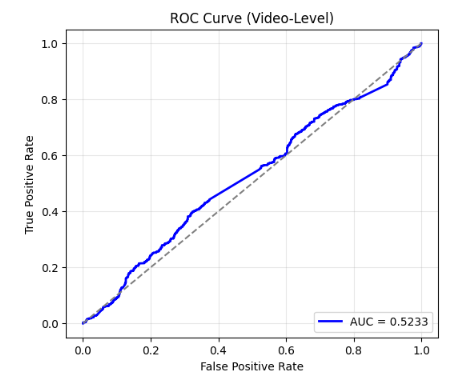

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, roc_curve
import matplotlib.pyplot as plt

FINETUNED_MODEL_PATH = "/kaggle/working/finetuned_DeepFakesON-Phys.h5"
DATASET_ROOT         = "/kaggle/input/datasets/mariaspasyuk/testframesfaces" 
IMG_SIZE             = (36, 36)
INFERENCE_BATCH_SIZE = 64
AGGREGATION_METHOD   = "mean" 
THRESHOLD            = 0.35


def load_model_safe(model_path):
    print(f"Загрузка модели: {model_path}")
    model = tf.keras.models.load_model(model_path, compile=False)
    print(f"Модель загружена. Входы: {[inp.shape for inp in model.inputs]}")
    return model

def load_video_frames(frame_dir, target_size=IMG_SIZE):
    frame_paths = sorted(Path(frame_dir).glob("*.png")) + sorted(Path(frame_dir).glob("*.jpg"))
    if not frame_paths:
        return None, None

    frames = []
    for p in frame_paths:
        img = cv2.imread(str(p))
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, target_size).astype(np.float32) / 255.0
        frames.append(img)

    if len(frames) == 0:
        return None, None

    raw = np.array(frames)  
    diff = np.zeros_like(raw)
    diff[1:] = raw[1:] - raw[:-1] 

    raw_nchw = np.transpose(raw, (0, 3, 1, 2))
    diff_nchw = np.transpose(diff, (0, 3, 1, 2))
    return raw_nchw, diff_nchw

def predict_video_score(model, frame_dir, batch_size=INFERENCE_BATCH_SIZE, agg_method=AGGREGATION_METHOD):
    raw, diff = load_video_frames(frame_dir)
    if raw is None:
        return None

    frame_scores = []
    for i in range(0, len(raw), batch_size):
        preds = model([raw[i:i+batch_size], diff[i:i+batch_size]], training=False).numpy()
        frame_scores.append(preds.flatten())

    frame_scores = np.concatenate(frame_scores)

    if agg_method == "mean":   return np.mean(frame_scores)
    elif agg_method == "median": return np.median(frame_scores)
    elif agg_method == "max":    return np.max(frame_scores)
    return np.mean(frame_scores)

def evaluate_frames_dataset(model, dataset_root, threshold=THRESHOLD):
    dataset_root = Path(dataset_root)
    video_dirs, y_true = [], []

    for label_name, label in [("real_frames_faces", 0), ("fake_frames_faces", 1)]:
        class_dir = dataset_root / label_name
        if not class_dir.exists():
            print(f"Папка {class_dir} не найдена. Пропускаем.")
            continue
        for vid_dir in class_dir.iterdir():
            if vid_dir.is_dir():
                video_dirs.append(vid_dir)
                y_true.append(label)

    print(f"Найдено {len(video_dirs)} видео-папок для тестирования.")

    y_scores, valid_dirs, valid_labels = [], [], []

    for vid_dir, lbl in tqdm(zip(video_dirs, y_true), total=len(video_dirs), desc="Videos"):
        score = predict_video_score(model, str(vid_dir))
        if score is not None:
            y_scores.append(score)
            valid_dirs.append(str(vid_dir))
            valid_labels.append(lbl)

    y_true = np.array(valid_labels)
    y_scores = np.array(y_scores)

    if len(y_scores) == 0:
        raise ValueError("Ни одно видео не обработано. Проверьте структуру папок и наличие кадров.")

    y_pred = (y_scores >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_scores)
    acc = accuracy_score(y_true, y_pred)

    print(f"AUC-ROC: {auc:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Средний score real: {np.mean(y_scores[y_true == 0]):.4f}")
    print(f"Средний score fake: {np.mean(y_scores[y_true == 1]):.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Video-Level)')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

    out_df = pd.DataFrame({
        "video_dir": valid_dirs,
        "true_label": y_true,
        "score": y_scores,
        "predicted_label": y_pred
    })
    out_path = "/kaggle/working/test_predictions_frames.csv"
    out_df.to_csv(out_path, index=False)
    print(f"предсказания сохранены: {out_path}")

    return y_true, y_scores, y_pred
if __name__ == "__main__":
    model = load_model_safe(FINETUNED_MODEL_PATH)
    y_true, y_scores, y_pred = evaluate_frames_dataset(model, DATASET_ROOT)

In [ ]:
!rm -rf /kaggle/working/*

In [ ]:
#(изменен и записан в файл репы)
import numpy as np
import os
import cv2

image_path = '/kaggle/input/datasets/mariaspasyuk/huawei-test'
image_name_video = []
face_cascade = cv2.CascadeClassifier('/kaggle/working/DeepFakesON-Phys/src/haarcascade_frontalface_default.xml')
video_files = [f for f in os.listdir(image_path) if f.endswith('.mp4')]
total = len(video_files)
print(f"Найдено {total} видео.")

for f in [f for f in os.listdir(image_path)]:

    if not(".mp4" in f): 
        continue
    
    carpeta= os.path.join(image_path, f)
    cap = cv2.VideoCapture(carpeta)
    frame_rate = cap.get(cv2.CAP_PROP_FPS)
    nFrames = cap.get(7)
    max_frames = int(nFrames)
    ruta_parcial = os.path.join('/kaggle/working/DeepFrames',f) 
    if not(os.path.exists(ruta_parcial)):
        os.makedirs(ruta_parcial);
    ruta_parcial2 = os.path.join('/kaggle/working/RawFrames',f) 
    if not(os.path.exists(ruta_parcial2)) :
        os.makedirs(ruta_parcial2);
    
    L = 36
    C_R=np.empty((L,L,max_frames))
    C_G=np.empty((L,L,max_frames))
    C_B=np.empty((L,L,max_frames))
    
    D_R=np.empty((L,L,max_frames))
    D_G=np.empty((L,L,max_frames))
    D_B=np.empty((L,L,max_frames))
    
    D_R2=np.empty((L,L,max_frames))
    D_G2=np.empty((L,L,max_frames))
    D_B2=np.empty((L,L,max_frames))
    
    medias_R = np.empty((L,L))
    medias_G = np.empty((L,L))
    medias_B = np.empty((L,L))
    
    desviaciones_R = np.empty((L,L))
    desviaciones_G = np.empty((L,L))
    desviaciones_B = np.empty((L,L))
    
    imagen = np.empty((L,L,3))
    
    medias_CR = np.empty((L,L))
    medias_CG = np.empty((L,L))
    medias_CB = np.empty((L,L))
    
    desviaciones_CR = np.empty((L,L))
    desviaciones_CG = np.empty((L,L))
    desviaciones_CB = np.empty((L,L))
    ka = 1
    
    
    while(cap.isOpened() and ka< max_frames):
        ret, frame = cap.read()
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.1, 4)
        for (x, y, w, h) in faces:
            face = frame[y:y + h, x:x + w]
            
       
        face = cv2.resize(face, (L,L), interpolation = cv2.INTER_AREA)
        C_R[:,:,ka] = face[:,:,0]
        C_G[:,:,ka] = face[:,:,1]
        C_B[:,:,ka] = face[:,:,2]
        
        
        if ka > 1:
            denom_R = C_R[:,:,ka] + C_R[:,:,ka-1] + 0.0001
            denom_G = C_G[:,:,ka] + C_G[:,:,ka-1] + 0.0001
            denom_B = C_B[:,:,ka] + C_B[:,:,ka-1] + 0.0001
            
            D_R[:,:,ka-1] = (C_R[:,:,ka] - C_R[:,:,ka-1]) / denom_R
            D_G[:,:,ka-1] = (C_G[:,:,ka] - C_G[:,:,ka-1]) / denom_G
            D_B[:,:,ka-1] = (C_B[:,:,ka] - C_B[:,:,ka-1]) / denom_B
        ka = ka+1
     
    
        
    for i in range(0,L):
        for j in range(0,L):
            medias_R[i,j]=np.mean(D_R[i,j,:]) 
            medias_G[i,j]=np.mean(D_G[i,j,:]) 
            medias_B[i,j]=np.mean(D_B[i,j,:]) 
            desviaciones_R[i,j]=np.std(D_R[i,j,:]) 
            desviaciones_G[i,j]=np.std(D_G[i,j,:]) 
            desviaciones_B[i,j]=np.std(D_B[i,j,:]) 
            
    for i in range(0,L):
        for j in range(0,L):
            medias_CR[i,j]=np.mean(C_R[i,j,:]) 
            medias_CG[i,j]=np.mean(C_G[i,j,:]) 
            medias_CB[i,j]=np.mean(C_B[i,j,:]) 
            desviaciones_CR[i,j]=np.std(C_R[i,j,:]) 
            desviaciones_CG[i,j]=np.std(C_G[i,j,:]) 
            desviaciones_CB[i,j]=np.std(C_B[i,j,:])         
            
    for k in range(0,max_frames):
        D_R2[:,:,k] = (C_R[:,:,k] - medias_CR)/(desviaciones_CR+000.1)
        D_G2[:,:,k] = (C_G[:,:,k] - medias_CG)/(desviaciones_CG+000.1)
        D_B2[:,:,k] = (C_B[:,:,k] - medias_CB)/(desviaciones_CB+000.1)
     


    for k in range(0,max_frames):
        
        imagen[:,:,0] = D_R2[:,:,k]
        imagen[:,:,1] = D_G2[:,:,k]
        imagen[:,:,2] = D_B2[:,:,k]

        imagen= np.uint8(imagen)
        
        nombre_salvar= os.path.join(ruta_parcial2,str(k)+'.png')
        cv2.imwrite(nombre_salvar, imagen)
        

    for k in range(0,max_frames):
        
        D_R[:,:,k] = (D_R[:,:,k] - medias_R)/(desviaciones_R+000.1)
        D_G[:,:,k] = (D_G[:,:,k] - medias_G)/(desviaciones_G+000.1)
        D_B[:,:,k] = (D_B[:,:,k] - medias_B)/(desviaciones_B+000.1)
        
    for k in range(0,max_frames):
        
        imagen[:,:,0] = D_R[:,:,k]
        imagen[:,:,1] = D_G[:,:,k]
        imagen[:,:,2] = D_B[:,:,k]
        
        imagen = np.clip(imagen, 0, 255) 
        imagen= np.uint8(imagen)

        nombre_salvar= os.path.join(ruta_parcial,str(k)+'.png')
        cv2.imwrite(nombre_salvar, imagen)            
        
    cap.release()
    cv2.destroyAllWindows()